# UAS DEEP LEARNING

DZHAHIRA SHAFA

090113822227150

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Konversi Annotation dari Format XML ke YOLO TXT

In [2]:
import os
import xml.etree.ElementTree as ET

classes = ["apple", "banana", "mixed", "orange"]

def convert_annotation(xml_file, txt_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # ambil ukuran gambar
    size = root.find("size")
    if size is None:
        print(f"[SKIP] size tidak ditemukan → {xml_file}")
        return

    w = int(size.find("width").text)
    h = int(size.find("height").text)

    # skip jika width/height invalid
    if w == 0 or h == 0:
        print(f"[SKIP] width/height = 0 → {xml_file}")
        return

    with open(txt_file, "w") as f:
        for obj in root.iter('object'):
            class_name = obj.find('name').text
            cls_id = classes.index(class_name)

            xmlbox = obj.find('bndbox')

            xmin = float(xmlbox.find('xmin').text)
            ymin = float(xmlbox.find('ymin').text)
            xmax = float(xmlbox.find('xmax').text)
            ymax = float(xmlbox.find('ymax').text)

            # Konversi ke format YOLO
            x_center = (xmin + xmax) / 2 / w
            y_center = (ymin + ymax) / 2 / h
            bw = (xmax - xmin) / w
            bh = (ymax - ymin) / h

            f.write(f"{cls_id} {x_center} {y_center} {bw} {bh}\n")


def process_folder(folder):
    for f in os.listdir(folder):
        if f.endswith(".xml"):
            xml_path = os.path.join(folder, f)
            txt_path = os.path.join(folder, f.replace(".xml", ".txt"))
            convert_annotation(xml_path, txt_path)

# Sesuaikan dengan lokasi di Google Colab
process_folder("/content/drive/MyDrive/UAS Deep learning/object_detection_split/train")
process_folder("/content/drive/MyDrive/UAS Deep learning/object_detection_split/val")
process_folder("/content/drive/MyDrive/UAS Deep learning/object_detection_split/test")

print("✓ Selesai! XML → YOLO TXT berhasil.")

[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/orange_42.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/banana_57.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/apple_17.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/orange_70.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/apple_20.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/banana_35.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/apple_43.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/orange_1.xml
[SKIP] width/height = 0 → /content/drive/MyDrive/UAS Deep learning/object_detection_split/train/orange_4.xml
[SKIP] width/he

Kode berfungsi untuk:

Membaca annotation VOC XML

Mengambil objek + bounding box

Mengubah koordinat ke format YOLO

Menyimpan annotation baru dalam file .txt


## Konfigurasi Dataset Menggunakan File data.yaml

In [3]:
%%writefile data.yaml
train: "/content/drive/MyDrive/UAS Deep learning/object_detection_split/train"
val: "/content/drive/MyDrive/UAS Deep learning/object_detection_split/val"

nc: 4
names:
  - apple
  - banana
  - mixed
  - orange


Writing data.yaml


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.6 MB/s eta 0:00:00


In [5]:
!cat data.yaml

train: "/content/drive/MyDrive/UAS Deep learning/object_detection_split/train"
val: "/content/drive/MyDrive/UAS Deep learning/object_detection_split/val"

nc: 4
names:
  - apple
  - banana
  - mixed
  - orange


File ini adalah pengaturan dataset agar YOLO (YOLOv8/YOLOv11) tahu:



*   lokasi data train & val
*   jumlah kelas
*   nama kelas



Format ini wajib ada untuk training model YOLO.

## Pelatihan Model YOLOv11 Menggunakan Dataset

In [6]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")   # model kecil, cepat
model.train(
    data="data.yaml",
    epochs=50,
    imgsz=240,
    batch=8
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=240, int8=False, iou=0.7, keras=False, kobj=1.0, line

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d0866cafc80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## Evaluasi Performa Model Menggunakan Metode Validation

In [11]:
model = YOLO("runs/detect/train/weights/best.pt")
results = model.val()


Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.9±3.1 ms, read: 7.6±10.2 MB/s, size: 38.0 KB)
val: Scanning /content/drive/MyDrive/UAS Deep learning/object_detection_split/val.cache... 53 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61/61 112.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6it/s 1.5s
                   all         61        103      0.781      0.864      0.871      0.645
                 apple         23         45      0.834      0.956      0.921      0.684
                banana         12         21      0.644      0.689      0.738       0.49
                orange         22         37      0.865      0.946      0.954      0.761
Speed: 2.7ms preprocess, 5.0ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to /conte

## Grafik evaluasi Matrix

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

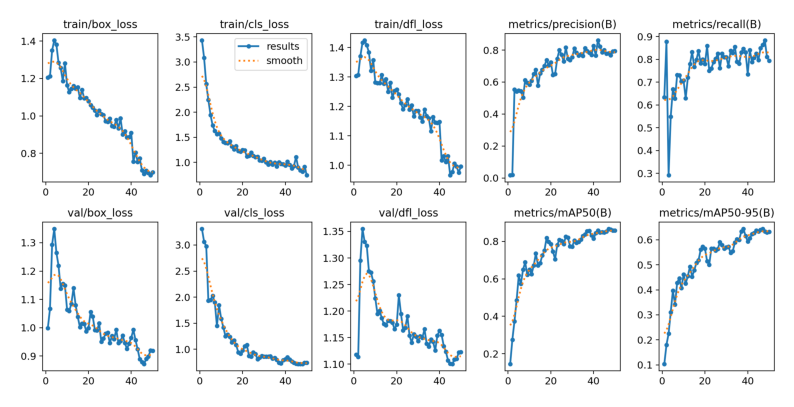

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("runs/detect/train/results.png")
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")

Dari grafik loss dan metrik selama 50 epoch, terlihat bahwa proses training berjalan stabil dan berhasil. Semua jenis loss (box_loss, cls_loss, dan dfl_loss) pada data train dan val terus menurun, yang berarti model semakin baik memahami objek dan bounding box.

Metrik evaluasi seperti precision, recall, mAP50, dan mAP50-95 terus meningkat setiap epoch, menunjukkan bahwa kemampuan model dalam mendeteksi objek semakin akurat.

Secara keseluruhan, grafik menunjukkan bahwa model berhasil belajar dengan baik, performanya meningkat stabil, dan hasil akhir memiliki akurasi deteksi yang cukup tinggi.

## Hasil gambar Prediksi


image 1/1 /content/drive/MyDrive/UAS Deep learning/object_detection_split/test/banana_77.jpg: 256x224 1 banana, 8.4ms
Speed: 0.8ms preprocess, 8.4ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 224)

image 1/1 /content/drive/MyDrive/UAS Deep learning/object_detection_split/test/orange_2.jpg: 224x256 2 oranges, 9.7ms
Speed: 0.8ms preprocess, 9.7ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 256)

image 1/1 /content/drive/MyDrive/UAS Deep learning/object_detection_split/test/banana_3.jpg: 192x256 1 banana, 8.7ms
Speed: 0.7ms preprocess, 8.7ms inference, 1.1ms postprocess per image at shape (1, 3, 192, 256)

image 1/1 /content/drive/MyDrive/UAS Deep learning/object_detection_split/test/orange_30.jpg: 256x256 1 orange, 8.0ms
Speed: 0.7ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/drive/MyDrive/UAS Deep learning/object_detection_split/test/apple_49.jpg: 256x256 1 apple, 7.6ms
Speed: 0.6ms preprocess,

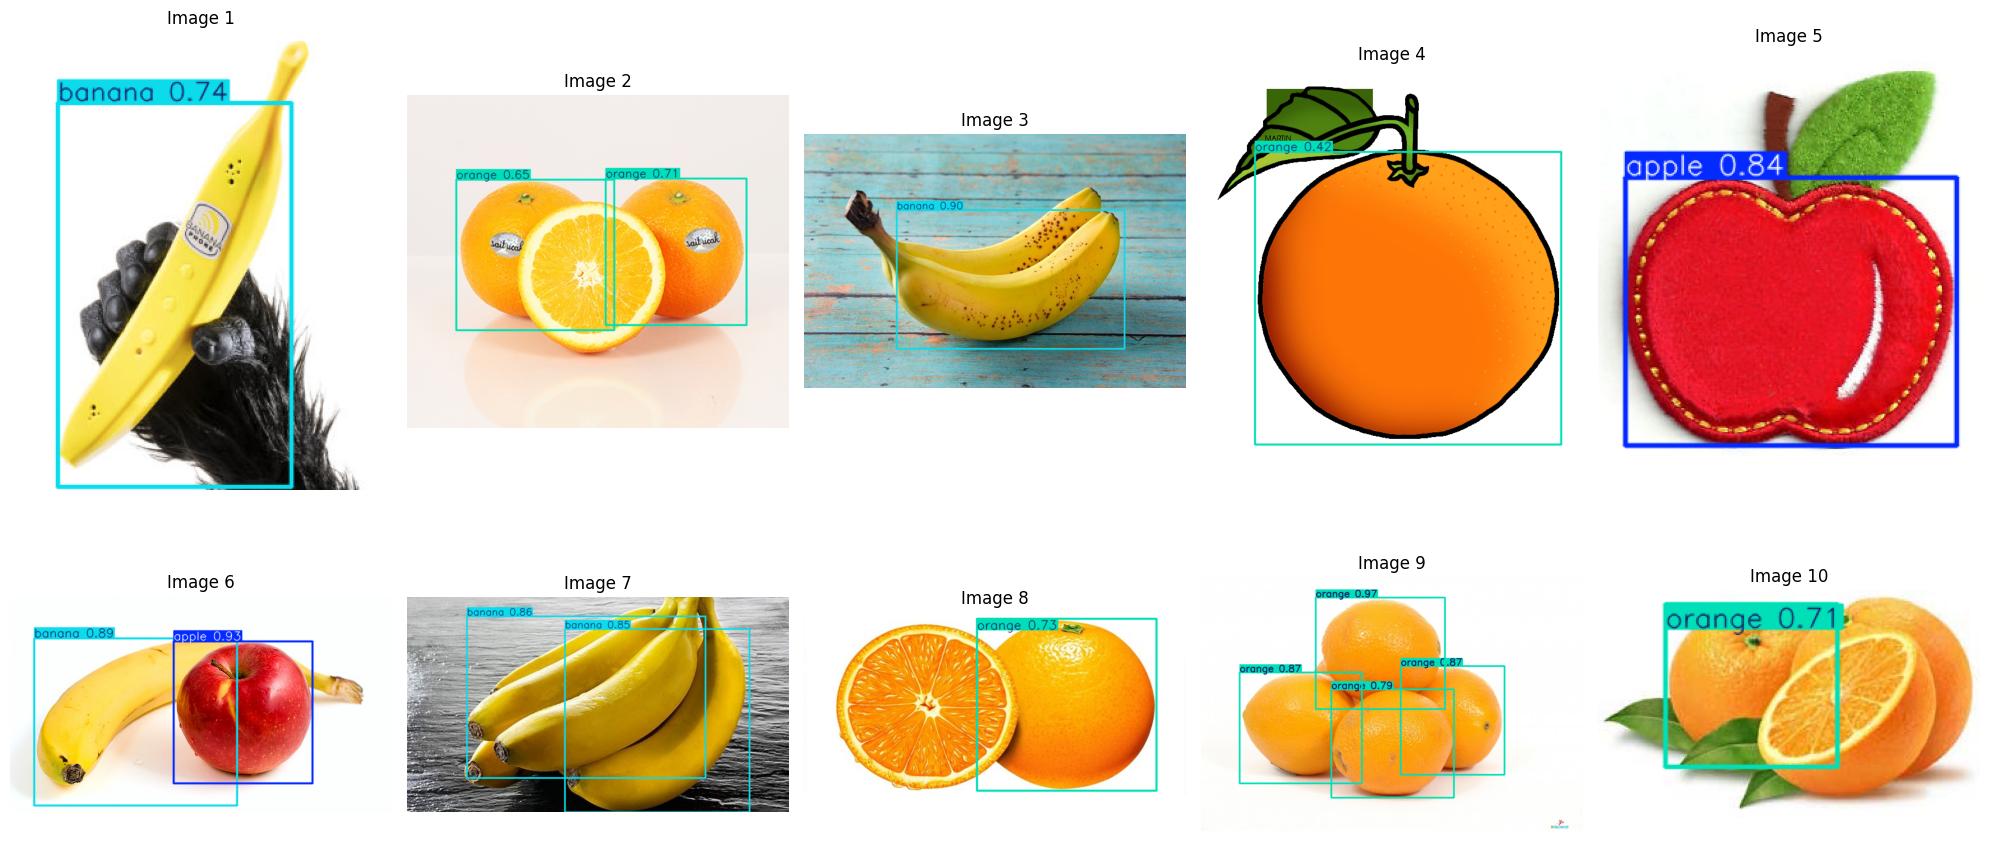

In [12]:
# ambil 10 gambar dari folder test
test_paths = glob.glob("/content/drive/MyDrive/UAS Deep learning/object_detection_split/test/*.jpg")[:10]

plt.figure(figsize=(20, 10))

for i, img_path in enumerate(test_paths):
    # jalankan prediksi (tanpa save)
    results = model(img_path)

    # ambil gambar hasil deteksi
    detected_img = results[0].plot()   # plot = gambar + bounding box

    # ubah BGR ke RGB
    detected_img = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i+1)
    plt.imshow(detected_img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Berdasarkan serangkaian proses yang telah dilakukan, mulai dari konversi anotasi XML ke format YOLO, penyusunan struktur dataset melalui file data.yaml, pelatihan model YOLOv11n, hingga evaluasi performa model, dapat disimpulkan bahwa sistem deteksi objek yang dibangun telah berjalan dengan baik. Adapun pembelajaran mesin mempelajari pola objek dari empat kelas yaitu apple, banana, mixed, dan orange dengan cukup baik. Hasil evaluasi menunjukkan bahwa model memiliki performa yang cukup tinggi dengan nilai precision, recall, serta mAP50 yang baik pada sebagian besar kelas. Meskipun demikian, performa kelas tertentu seperti banana masih lebih rendah dibanding kelas lainnya. Secara keseluruhan, model mampu mendeteksi objek pada citra uji dengan akurasi yang memadai, sehingga dapat disimpulkan bahwa pendekatan ini efektif digunakan untuk tugas deteksi objek buah.